# How Has AI Research Exploded? An Analysis of arXiv Papers

**Author:** Debora Princepe  
**Dataset:** [arXiv Dataset — Cornell University](https://www.kaggle.com/datasets/Cornell-University/arxiv)  
**Tools:** Python, Pandas, Matplotlib, Scipy

## Overview
arXiv is the primary preprint server for physics, mathematics, computer science, and increasingly biology and economics.
With over 3 million papers spanning decades, it offers a unique lens into how scientific research evolves.
In this project, I analyze the rise of AI research between 1991 and 2024: when it accelerated, which subfields dominate, and what the most influential topics have been over time.

## Questions I'll answer:
1. How has the volume of AI/ML papers grown over time?
2. Which AI subfields are growing fastest?
3. What keywords define each era of AI research?
4. How does AI growth compare to other fields (physics, math, biology)?

## 0. Setup

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from datetime import datetime
from scipy.stats import linregress
import re

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Libraries loaded.')

Libraries loaded.


## 1. Load the Data

The dataset is large (~4GB). We read it in chunks and keep only the fields we need.

**Fields we'll use:**
- `id` — unique paper ID
- `title` — paper title
- `categories` — arXiv category codes (e.g. `cs.AI`, `cs.LG`)
- `versions` — list of version dicts; we'll extract the first submission date

In [2]:
# arXiv category dictionary
CATEGORY_NAMES = {
    'cs.AI': 'Artificial Intelligence',
    'cs.LG': 'Machine Learning',
    'cs.CV': 'Computer Vision',
    'cs.CL': 'Computation & Language (NLP)',
    'cs.NE': 'Neural & Evolutionary Computing',
    'cs.RO': 'Robotics',
    'stat.ML': 'Statistics - Machine Learning',
    'math.ST': 'Statistics Theory',
    'q-bio': 'Quantitative Biology',
    'physics': 'Physics',
    'cond-mat': 'Condensed Matter',
    'math': 'Mathematics',
    'econ': 'Economics',
    'eess': 'Electrical Engineering'
}

# Core AI/ML categories we'll focus on
AI_CATEGORIES = {'cs.AI', 'cs.LG', 'cs.CV', 'cs.CL', 'cs.NE', 'stat.ML'}

In [ ]:
# Read the JSON file

FILEPATH = 'arxiv-metadata-oai-snapshot.json' 

records = []

with open(FILEPATH, 'r') as f:
    for i, line in enumerate(f):
        paper = json.loads(line)
        
        # Extract first submission date from versions
        try:
            date_str = paper['versions'][0]['created']
            date = datetime.strptime(date_str, '%a, %d %b %Y %H:%M:%S %Z')
            year = date.year
        except:
            year = None
        
        records.append({
            'id': paper.get('id'),
            'title': paper.get('title', '').replace('\n', ' ').strip(),
            # 'abstract': paper.get('abstract', '').replace('\n', ' ').strip(),
            'categories': paper.get('categories', ''),
            # 'authors': paper.get('authors', ''),
            'year': year
        })
        

df = pd.DataFrame(records)
print(f'\nTotal records: {len(df):,}')
df.head()


Total records: 3,107,014


,id,title,categories,year
0,0704.0001,Calculation of prompt diphoton production cros...,hep-ph,2007
1,0704.0002,Sparsity-certifying Graph Decompositions,math.CO cs.CG,2007
2,0704.0003,The evolution of the Earth-Moon system based o...,physics.gen-ph,2007
3,0704.0004,A determinant of Stirling cycle numbers counts...,math.CO,2007
4,0704.0005,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,math.CA math.FA,2007


In [4]:
# Basic cleanup
df = df.dropna(subset=['year', 'categories'])
df['year'] = df['year'].astype(int)

# Filter to reasonable range (arXiv started in 1991)
df = df[(df['year'] >= 1991) & (df['year'] <= 2024)]

# Flag AI papers
df['is_ai'] = df['categories'].apply(
    lambda cats: any(c in AI_CATEGORIES for c in cats.split())
)

print(f'Total papers: {len(df):,}')
print(f'AI papers: {df["is_ai"].sum():,} ({df["is_ai"].mean()*100:.1f}%)')

Total papers: 2,638,772
AI papers: 410,152 (15.5%)


## 2. Question 1: How has AI paper volume grown over time?

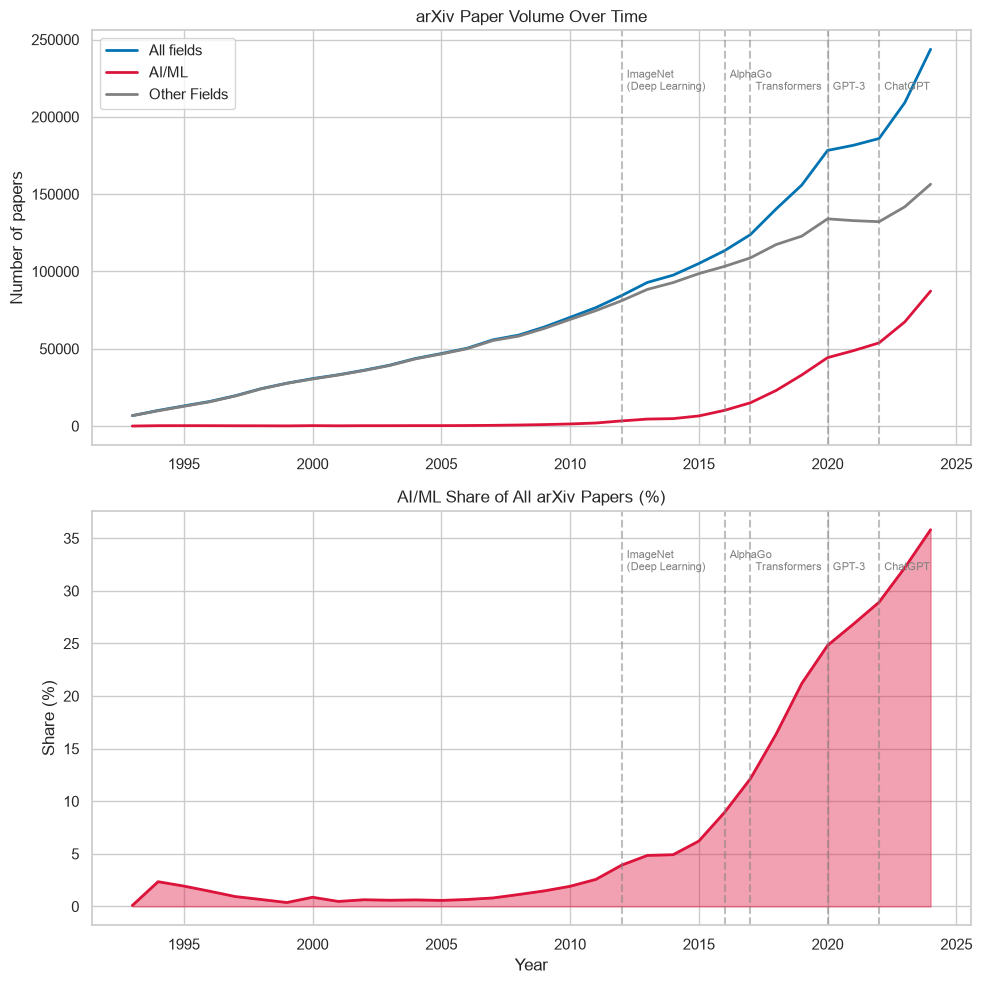

In [5]:
# Papers per year
total_by_year = df.groupby('year').size().reset_index(name='total')
ai_by_year = df[df['is_ai']].groupby('year').size().reset_index(name='ai_papers')
yearly = total_by_year.merge(ai_by_year, on='year')
yearly['ai_share'] = yearly['ai_papers'] / yearly['total'] * 100

# Key AI milestones
milestones = {
    2012: 'ImageNet\n(Deep Learning)',
    2016: 'AlphaGo \n',
    2017: 'Transformers',
    2020: 'GPT-3',
    2022: 'ChatGPT'
}

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot 1: absolute volume
ax = axes[0]
ax.plot(yearly['year'], yearly['total'], label='All fields', linewidth=2)
ax.plot(yearly['year'], yearly['ai_papers'], label='AI/ML', linewidth=2, color='crimson')
ax.plot(yearly['year'], yearly['total'] - yearly['ai_papers'], label='Other Fields', linewidth=2, color='gray')
for year, label in milestones.items():
    ax.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
    ax.text(year + 0.2, ax.get_ylim()[1] * 0.85, label, fontsize=8, color='gray')
ax.set_title('arXiv Paper Volume Over Time')
ax.set_ylabel('Number of papers')
ax.legend()

# Plot 2: AI share
ax2 = axes[1]
ax2.fill_between(yearly['year'], yearly['ai_share'], alpha=0.4, color='crimson')
ax2.plot(yearly['year'], yearly['ai_share'], color='crimson', linewidth=2)
for year, label in milestones.items():
    ax2.axvline(x=year, color='gray', linestyle='--', alpha=0.5)
    ax2.text(year + 0.2, ax2.get_ylim()[1] * 0.85, label, fontsize=8, color='gray')
ax2.set_title('AI/ML Share of All arXiv Papers (%)')
ax2.set_ylabel('Share (%)')
ax2.set_xlabel('Year')

plt.tight_layout()
plt.savefig('figures/volume_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

- AI/ML submissions accelerated sharply after 2012, with a curve that visually outpaces all other fields considered.

- Submission rates across all fields slowed in 2020, a pattern more likely driven by the COVID-19 pandemic than by the contemporaneous release of GPT-3. AI-related papers were a notable exception, sustaining positive growth even during this period. 

- The subsequent release of ChatGPT appears to coincide with a recovery in submission rates across all fields, suggesting that AI-assisted writing may have accelerated the pace of manuscript preparation and submission.

- When considering papers with any AI/ML category tag, the share grew from roughly 5% in 2014 to over 35% in 2024, reflecting the explosion of core AI research and rapid permeation of machine learning methods into other fields.

## 3. Question 2: Which AI subfields are growing fastest?

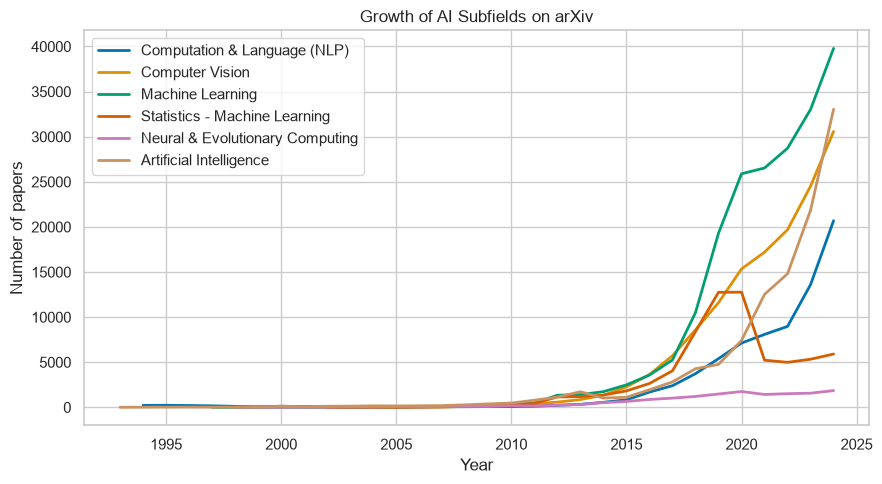

Annual growth rates (log-linear fit, 2010–2024):

                       category  annual_growth_rate  doubling_time_years  r_squared
   Computation & Language (NLP)            0.392382             1.766510   0.977850
               Machine Learning            0.354700             1.954179   0.962043
                Computer Vision            0.352090             1.968663   0.971356
        Artificial Intelligence            0.285703             2.426112   0.954116
  Statistics - Machine Learning            0.222210             3.119339   0.720657
Neural & Evolutionary Computing            0.184806             3.750683   0.883234


In [ ]:
# Explode categories — one row per category per paper
ai_papers = df[df['is_ai']].copy()
ai_papers['category_list'] = ai_papers['categories'].str.split()
ai_exploded = ai_papers.explode('category_list')
ai_exploded = ai_exploded[ai_exploded['category_list'].isin(AI_CATEGORIES)]

# Count by category and year
cat_year = ai_exploded.groupby(['year', 'category_list']).size().reset_index(name='count')
cat_year['category_name'] = cat_year['category_list'].map(CATEGORY_NAMES)

# Plot
plt.figure(figsize=(9,5))
for cat in AI_CATEGORIES:
    data = cat_year[cat_year['category_list'] == cat]
    plt.plot(data['year'], data['count'], label=CATEGORY_NAMES.get(cat, cat), linewidth=2)

plt.title('Growth of AI Subfields on arXiv')
plt.xlabel('Year')
plt.ylabel('Number of papers')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('figures/growth_subfields.png', dpi=150, bbox_inches='tight')
plt.show()


# Fit log-linear model per category (exponential growth rate)
# log(count) = a + r*year  →  r is the annual growth rate
growth_rates = []

for cat in AI_CATEGORIES:
    data = cat_year[(cat_year['category_list'] == cat) & (cat_year['year'] >= 2010)].copy()
    if len(data) < 5:
        continue
    data = data[data['count'] > 0]
    log_count = np.log(data['count'])
    slope, intercept, r_value, p_value, _ = linregress(data['year'], log_count)
    growth_rates.append({
        'category': CATEGORY_NAMES.get(cat, cat),
        'annual_growth_rate': slope,
        'doubling_time_years': np.log(2) / slope,
        'r_squared': r_value**2,
        'p_value': p_value
    })

rates_df = pd.DataFrame(growth_rates).sort_values('annual_growth_rate', ascending=False)

# Display
print("Annual growth rates (log-linear fit, 2010–2024):\n")
print(rates_df[['category', 'annual_growth_rate', 'doubling_time_years', 'r_squared']].to_string(index=False))

- The data reveals a shift in how AI research is framed and produced: the older umbrella of "*Statistics - Machine Learning*" has given way to more specialized and application-driven subfields. The fastest growing categories since 2010 are *Computation & Language (NLP)* (39% per year), *Machine Learning* (35%), and *Computer Vision* (35%), all with doubling times under 2 years. This suggests that the explosion in AI output is not monolithic, but driven by specific application domains, with language models emerging as the dominant frontier in recent years.

## 4. Question 3: What keywords define each era of AI?

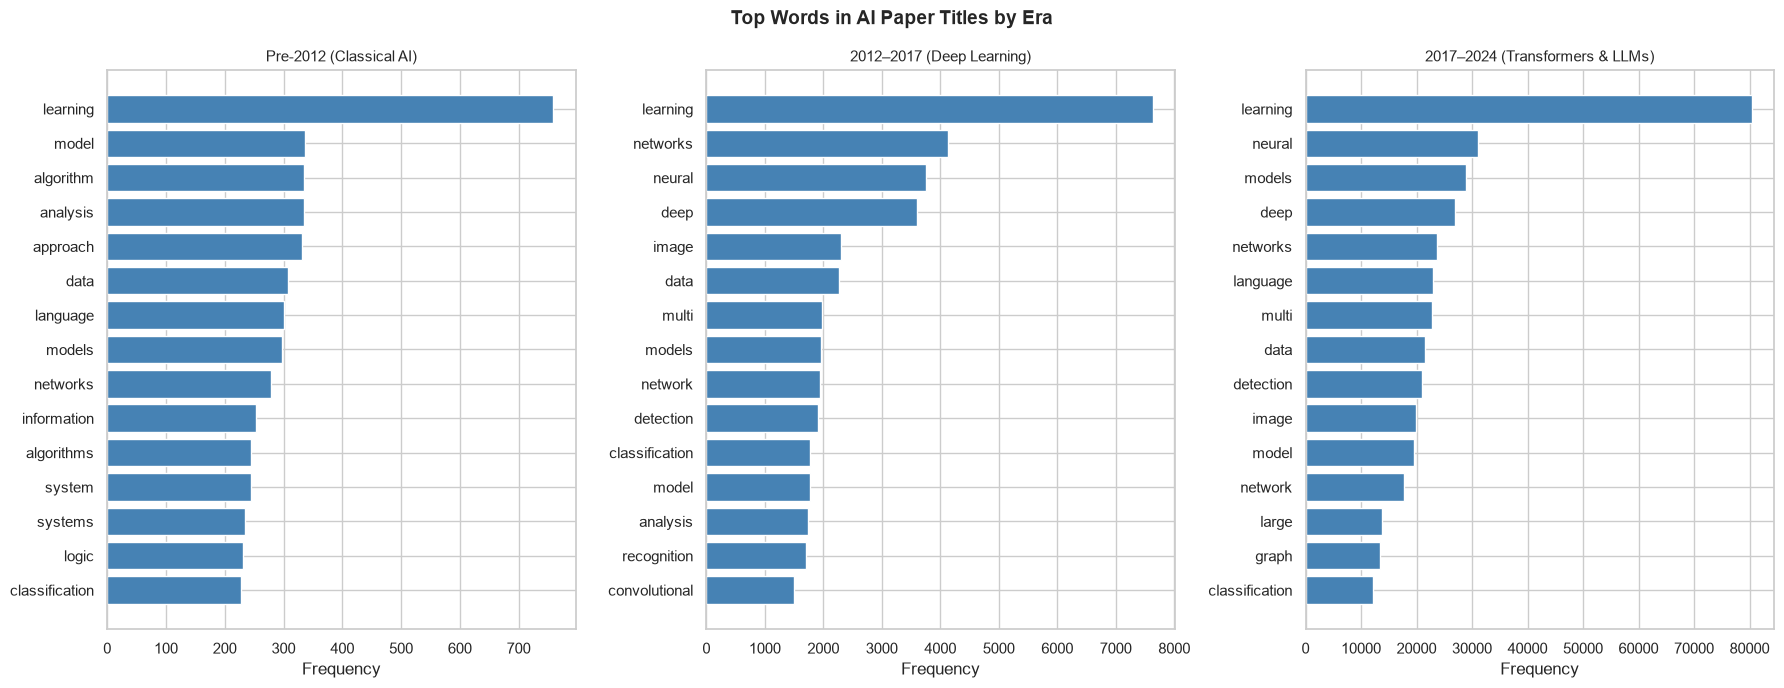

STABLE: classification, learning
EMERGED: deep, detection, graph, image, large, multi, network, neural
ROSE: models, networks
FELL: data, model
DISAPPEARED THEN RETURNED: language
DISAPPEARED: algorithm, algorithms, analysis, approach, information, logic, system, systems
DEEP LEARNING ONLY: convolutional, recognition


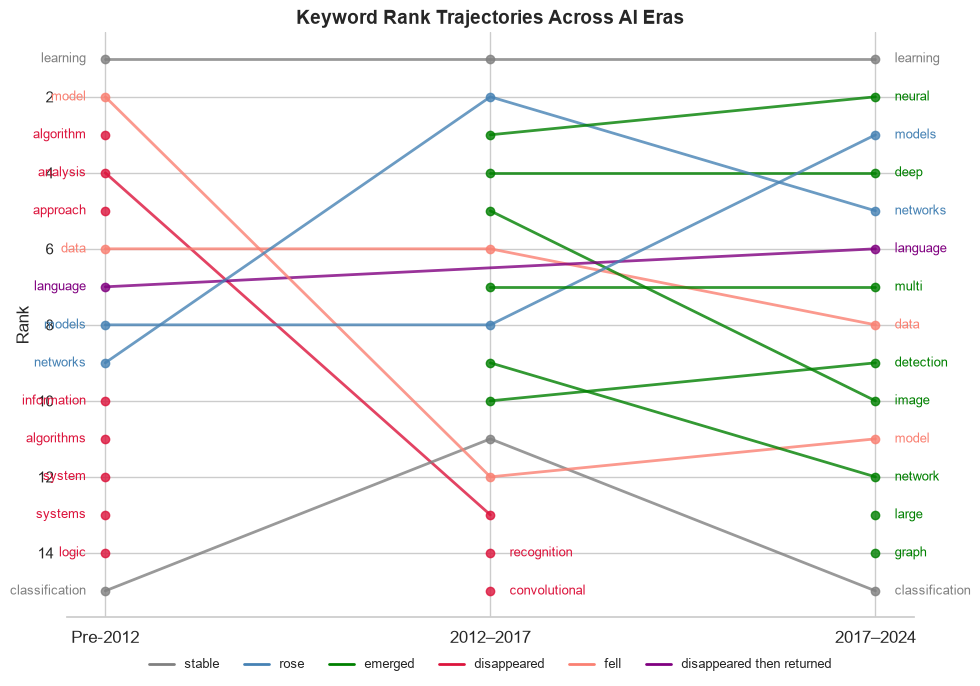

In [ ]:
# Stopwords to remove
STOPWORDS = {
    'a', 'an', 'the', 'of', 'in', 'for', 'on', 'with', 'and', 'to',
    'via', 'using', 'based', 'from', 'by', 'its', 'as', 'is', 'are',
    'we', 'our', 'this', 'that', 'it', 'at', 'be', 'or', 'not'
}

def top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', text.lower())
        words.extend([w for w in tokens if w not in STOPWORDS])
    return Counter(words).most_common(n)

eras = {
    'Pre-2012 (Classical AI)': df[df['is_ai'] & (df['year'] < 2012)]['title'],
    '2012–2017 (Deep Learning)': df[df['is_ai'] & (df['year'].between(2012, 2017))]['title'],
    '2017–2024 (Transformers & LLMs)': df[df['is_ai'] & (df['year'] > 2017)]['title']
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (era_name, texts) in zip(axes, eras.items()):
    words, counts = zip(*top_words(texts, n=15))
    ax.barh(list(reversed(words)), list(reversed(counts)), color='steelblue')
    ax.set_title(era_name, fontsize=11)
    ax.set_xlabel('Frequency')

plt.suptitle('Top Words in AI Paper Titles by Era', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Build rank dataframe from your eras_words dict
eras_words = {era_name: top_words(texts, n=15) for era_name, texts in eras.items()}
era_names = list(eras_words.keys())

rank_data = {}
for era_name, word_counts in eras_words.items():
    rank_data[era_name] = {word: rank+1 for rank, (word, count) in enumerate(word_counts)}

# All words that appear in at least one era
all_words = set()
for counts in eras_words.values():
    all_words.update([w for w, _ in counts])

# Build rank table — NaN if word absent from that era
rank_df = pd.DataFrame(index=sorted(all_words), columns=era_names)
for era_name, ranks in rank_data.items():
    for word, rank in ranks.items():
        rank_df.loc[word, era_name] = rank

rank_df = rank_df.astype(float)

# Classify each word by trajectory
def classify(row):
    e1, e2, e3 = row['Pre-2012 (Classical AI)'], row['2012–2017 (Deep Learning)'], row['2017–2024 (Transformers & LLMs)']
    present = [not pd.isna(x) for x in [e1, e2, e3]]
    if present == [False, False, True] or present == [False, True, True]:
        return 'emerged'                      
    elif present == [False, True, False]:
        return 'deep learning only'          
    elif present == [True, False, False] or present == [True, True, False]:
        return 'disappeared'                  
    elif present == [True, False, True]:
        return 'disappeared then returned'    
    elif e3 > e1:
        return 'fell'
    elif e3 < e1:
        return 'rose'
    else:
        return 'stable'

rank_df['trajectory'] = rank_df.apply(classify, axis=1)

# Show each group
for traj in ['stable','emerged', 'rose', 'fell', 'disappeared then returned', 'disappeared','deep learning only']:
    words = rank_df[rank_df['trajectory'] == traj].index.tolist()
    if words:
        print(f"{traj.upper()}: {', '.join(words)}")

words_to_plot = rank_df.index.tolist()

trajectory_colors = {
    'stable':                   'gray',
    'rose':                     'steelblue',
    'emerged':                  'green',
    'disappeared':              'crimson',
    'fell':                     'salmon',
    'disappeared then returned':'purple',
    'deep learning only':       'crimson'
}

era_labels = ['Pre-2012', '2012–2017', '2017–2024']
x = [0, 1, 2]

fig, ax = plt.subplots(figsize=(10, 7))

for word in words_to_plot:
    if word not in rank_df.index:
        continue
    row = rank_df.loc[word]
    ranks = [row[era] for era in era_names]
    traj = row['trajectory']
    color = trajectory_colors.get(traj, 'gray')

    # Only plot where rank exists
    x_valid = [xi for xi, r in zip(x, ranks) if pd.notna(r)]
    y_valid = [r for r in ranks if pd.notna(r)]

    ax.plot(x_valid, y_valid, marker='o', linewidth=2, color=color, alpha=0.8)
    
    # Label at first and last point
    if pd.notna(ranks[0]):
        ax.text(-0.05, ranks[0], word, ha='right', va='center', fontsize=9, color=color)
    if pd.notna(ranks[-1]):
        ax.text(2.05, ranks[-1], word, ha='left', va='center', fontsize=9, color=color)

deep_only = rank_df[rank_df[ "trajectory"] == "deep learning only"]
ax.text(1.05, deep_only.iloc[0]['2012–2017 (Deep Learning)'], deep_only.index[0], ha='left', va='center', fontsize=9, color='crimson')
ax.text(1.05, deep_only.iloc[1]['2012–2017 (Deep Learning)'], deep_only.index[1], ha='left', va='center', fontsize=9, color='crimson')

# Invert y-axis — rank 1 at top
ax.invert_yaxis()
ax.set_xticks(x)
ax.set_xticklabels(era_labels, fontsize=12)
ax.set_ylabel('Rank')
ax.set_title('Keyword Rank Trajectories Across AI Eras', fontsize=14, fontweight='bold')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[['top', 'right', 'left']].set_visible(False)

# Legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=c, linewidth=2, label=t)
                   for t, c in trajectory_colors.items()]
legend_elements.remove(next(e for e in legend_elements if e.get_label() == 'deep learning only'))
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), fontsize=9, ncol=6, frameon=False)

plt.tight_layout()
plt.savefig('figures/keyword_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

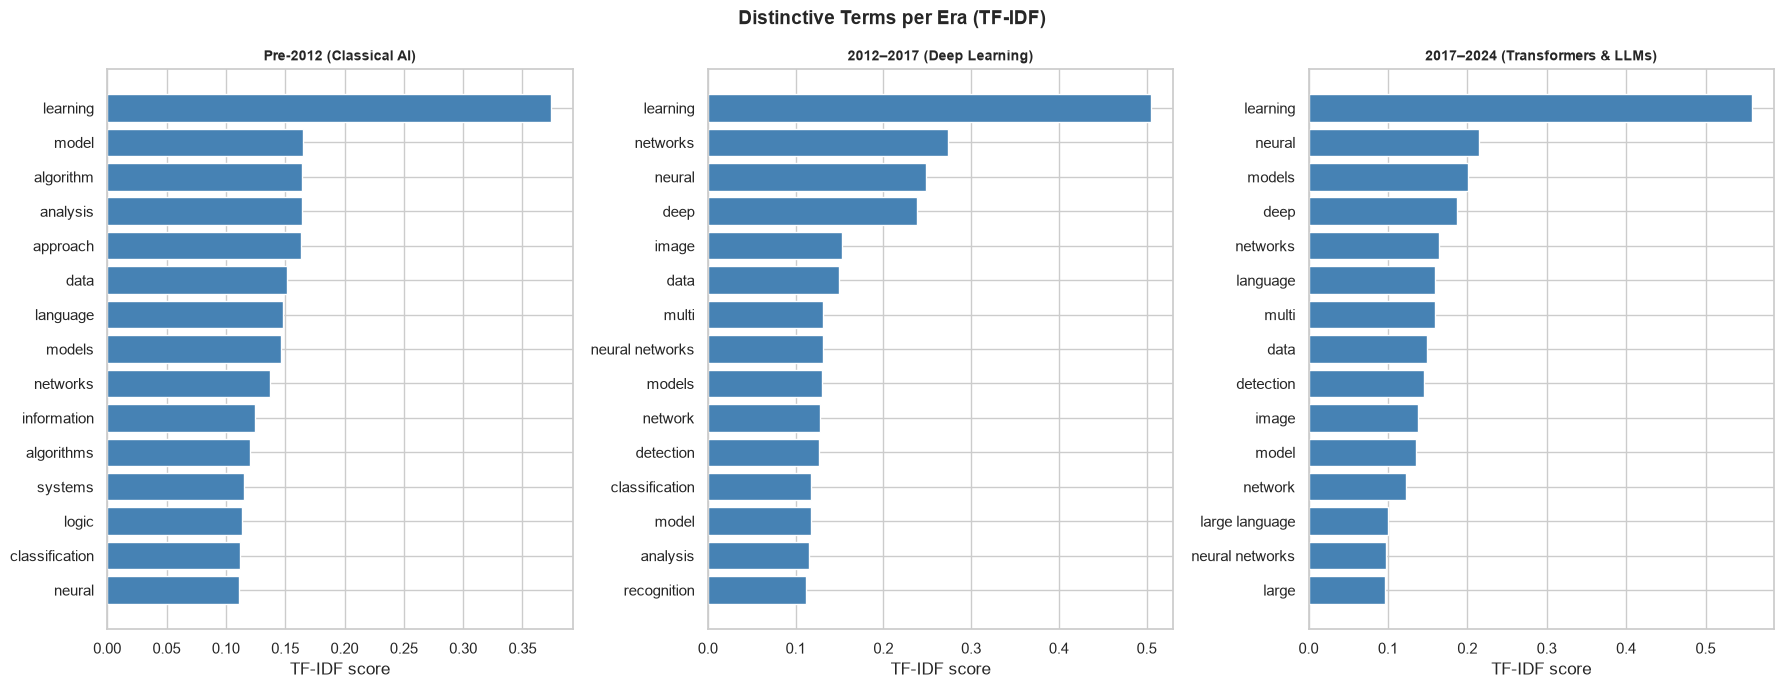

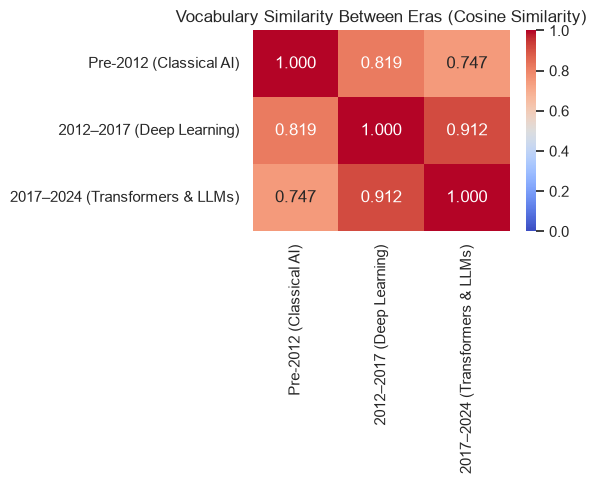

In [59]:
# A deeper analysis of distinctive terms per era can be done using TF-IDF (Term Frequency-Inverse Document Frequency). This method highlights words that are important in one era compared to others.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

combined_stopwords = list(ENGLISH_STOP_WORDS) + list(STOPWORDS)

# Build one "document" per era — concatenate all titles
era_docs = {}
for era_name, texts in eras.items():
    era_docs[era_name] = ' '.join(texts.tolist())

# Fit TF-IDF across the 3 era-documents
vectorizer = TfidfVectorizer(
    stop_words=combined_stopwords,
    min_df=1,
    ngram_range=(1, 2)  # include bigrams — catches "large language", "deep learning", etc.
)

tfidf_matrix = vectorizer.fit_transform(era_docs.values())
feature_names = vectorizer.get_feature_names_out()

# Top distinctive terms per era
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=era_docs.keys(),
    columns=feature_names
)

top_n = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, era_name in zip(axes, era_docs.keys()):
    top_terms = tfidf_df.loc[era_name].sort_values(ascending=False).head(top_n)
    ax.barh(list(reversed(top_terms.index)), list(reversed(top_terms.values)),
            color='steelblue')
    ax.set_title(era_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('TF-IDF score')

plt.suptitle('Distinctive Terms per Era (TF-IDF)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# compute the similarity between eras based on their TF-IDF vectors using cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(tfidf_matrix)
sim_df = pd.DataFrame(sim_matrix, index=era_docs.keys(), columns=era_docs.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(sim_df, annot=True, fmt='.3f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Vocabulary Similarity Between Eras (Cosine Similarity)')
plt.tight_layout()
plt.show()

- Core vocabulary remained stable: "*learning*", "*classification*", and "*data*" persist across all eras as foundational concepts regardless of the dominant paradigm.

- A subtle but telling shift: "*model*" fell from 2nd to 12th place while "*models*" rose from 8th to 3rd, reflecting a move from discussing a single model as a methodological contribution to comparing and evaluating families of models.

- Classical computer science vocabulary disappeared entirely: "*algorithm(s)*", "*analysis*", "*approach*", "*logic*", "*system(s)*", and "*information*", hallmarks of symbolic AI, are absent from recent titles, marking a paradigm shift away from rule-based reasoning toward data-driven methods.

- "*Language*" traced the arc of the field itself: present in classical AI, absent during the computer vision-dominated deep learning wave, then returning strongly with transformers and LLMs.

- Computer vision terms peaked and faded: "*convolutional*" and "*recognition*" defined 2012–2017 but did not persist, replaced by broader vocabulary as the field matured; at the same time, "*neural*" and "*deep*" remain central through today.

- New frontier vocabulary emerged post-2017:  "*large*", "*graph*", "*detection*", and "*multi*" reflect the diversification of AI applications, from large language models to graph neural networks and multi-task learning.

## 5. Question 4: Is AI growing faster than other fields (and reshaping them)?

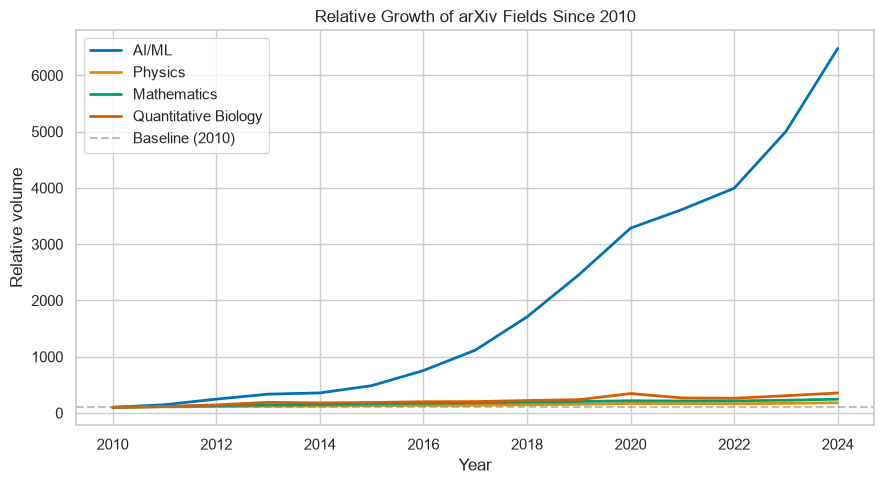

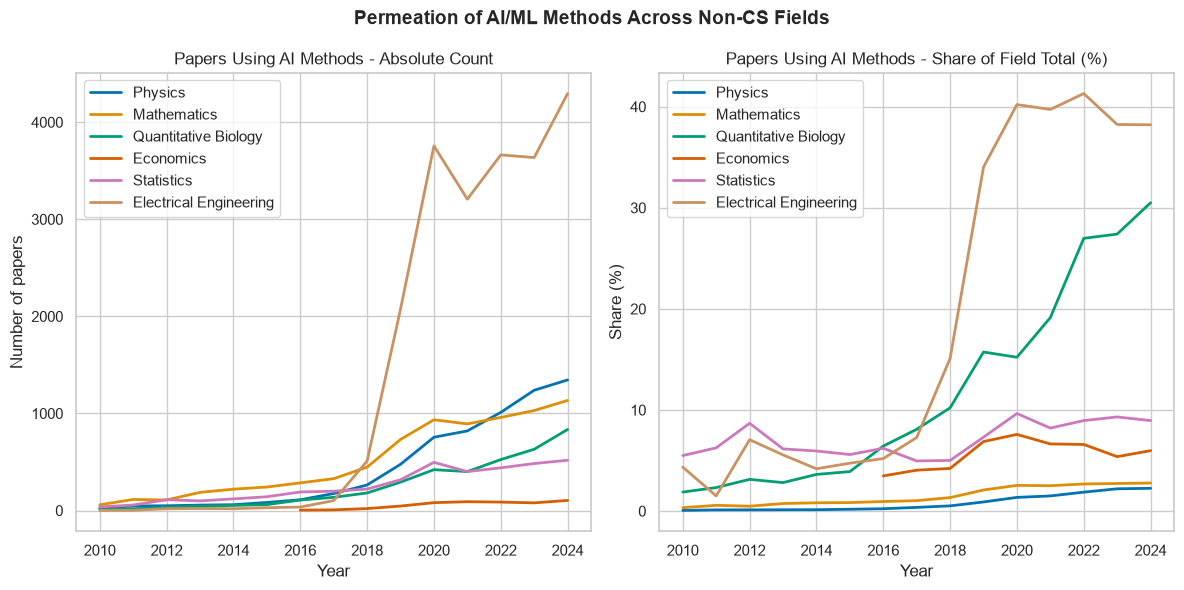

In [44]:
# Define field filters by category prefix
fields = {
    'AI/ML': lambda cats: any(c in AI_CATEGORIES for c in cats.split()),
    'Physics': lambda cats: any(c.startswith('physics') or c.startswith('cond-mat') or c.startswith('hep') for c in cats.split()),
    'Mathematics': lambda cats: any(c.startswith('math.') for c in cats.split()),
    'Quantitative Biology': lambda cats: any(c.startswith('q-bio') for c in cats.split()),
}

field_yearly = {}
for field_name, filter_fn in fields.items():
    counts = df[df['categories'].apply(filter_fn)].groupby('year').size()
    field_yearly[field_name] = counts

# Normalize to 2010
BASE_YEAR = 2010
plt.figure(figsize=(9, 5))
    
field_fold = {}
for field_name, counts in field_yearly.items():
    base = counts.get(BASE_YEAR, None)
    if base and base > 0:
        normalized = (counts / base) * 100
        normalized = normalized[normalized.index >= BASE_YEAR]
        fold = normalized.iloc[-1] / 100
        field_fold[field_name] = round(fold, 2)
        plt.plot(normalized.index, normalized.values, label=field_name, linewidth=2)

plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5, label='Baseline (2010)')
plt.title('Relative Growth of arXiv Fields Since 2010')
plt.xlabel('Year')
plt.ylabel('Relative volume')
plt.legend()
plt.tight_layout()
plt.savefig('figures/relative_growth.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare primary vs any AI category
df['primary_category'] = df['categories'].str.split().str[0]
df['is_ai_primary'] = df['primary_category'].isin(AI_CATEGORIES)

# Papers with AI as primary vs secondary category
recent = df[df['year'] >= 2010].copy()
recent['ai_type'] = 'non-AI'
recent.loc[recent['is_ai_primary'], 'ai_type'] = 'Core AI'
recent.loc[recent['is_ai'] & ~recent['is_ai_primary'], 'ai_type'] = 'AI applied to other fields'

# # By year
# breakdown = recent.groupby(['year', 'ai_type']).size().unstack(fill_value=0)
# breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0) * 100

# # Plot
# breakdown_pct[['Core AI', 'AI applied to other fields']].plot(
#     kind='area', stacked=True, figsize=(9,5),
#     color=['crimson', 'salmon']
# )
# plt.title('Core AI vs AI Applied to Other Fields — Share of arXiv Submissions')
# plt.ylabel('Share (%)')
# plt.xlabel('Year')
# plt.tight_layout()
# plt.show()

# Papers where AI is secondary, excluding CS as primary field
ai_secondary = df[df['is_ai'] & ~df['is_ai_primary']].copy()
ai_secondary = ai_secondary[~ai_secondary['primary_category'].str.startswith('cs')]

# Broad field mapping (without CS)
def broad_field(cat):
    if cat.startswith('physics') or cat.startswith('cond-mat') or cat.startswith('hep') or cat.startswith('astro'):
        return 'Physics'
    elif cat.startswith('math'):
        return 'Mathematics'
    elif cat.startswith('q-bio'):
        return 'Quantitative Biology'
    elif cat.startswith('econ'):
        return 'Economics'
    elif cat.startswith('eess'):
        return 'Electrical Engineering'
    elif cat.startswith('stat'):
        return 'Statistics'
    else:
        return 'Other'

ai_secondary['broad_field'] = ai_secondary['primary_category'].apply(broad_field)

# Total papers per field (all years, excluding cs)
df_non_cs = df[~df['primary_category'].str.startswith('cs')].copy()
df_non_cs['broad_field'] = df_non_cs['primary_category'].apply(broad_field)

# Count AI-tagged papers and total papers per field per year
ai_by_field_year = ai_secondary.groupby(['year', 'broad_field']).size().reset_index(name='ai_count')
total_by_field_year = df_non_cs.groupby(['year', 'broad_field']).size().reset_index(name='total_count')

merged = ai_by_field_year.merge(total_by_field_year, on=['year', 'broad_field'])
merged['ai_share'] = merged['ai_count'] / merged['total_count'] * 100
merged = merged[merged['year'] >= BASE_YEAR]

# Plot: two panels side by side
fields_to_plot = ['Physics', 'Mathematics', 'Quantitative Biology', 'Economics', 'Statistics', 'Electrical Engineering']
palette = dict(zip(fields_to_plot, sns.color_palette('colorblind', len(fields_to_plot))))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# absolute counts
ax = axes[0]
for field in fields_to_plot:
    data = merged[merged['broad_field'] == field]
    ax.plot(data['year'], data['ai_count'], label=field, linewidth=2, color=palette[field])
ax.set_title('Papers Using AI Methods - Absolute Count')
ax.set_xlabel('Year')
ax.set_ylabel('Number of papers')
ax.legend()

# share relative to each field's total
ax2 = axes[1]
for field in fields_to_plot:
    data = merged[merged['broad_field'] == field]
    ax2.plot(data['year'], data['ai_share'], label=field, linewidth=2, color=palette[field])
ax2.set_title('Papers Using AI Methods - Share of Field Total (%)')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share (%)')
ax2.legend()

plt.suptitle('Permeation of AI/ML Methods Across Non-CS Fields', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/permeation.png', dpi=150, bbox_inches='tight')
plt.show()

- AI/ML experienced by far the fastest growth, with submissions increasing nearly 65-fold, compared with just 2- to 4-fold increases in Physics, Mathematics, and Quantitative Biology.

- All fields showed a growing number of papers with AI/ML category tags. Electrical Engineering stands out both in absolute volume and in share, which is expected given its natural overlap with AI methods. More surprisingly, Quantitative Biology now shows nearly 30% of papers tagged with AI/ML categories, reflecting the rapid adoption of machine learning in biological data analysis over the past decade.

## 6. Conclusions


- **When did AI take off?**

    AI/ML submissions accelerated sharply after 2012 and grew at a rate far exceeding all other fields, reaching a nearly 65-fold increase in volume by 2024, compared to 2–4x growth in physics, mathematics, and quantitative biology over the same period. The share of AI-tagged papers on arXiv grew from roughly 5% in 2014 to over 35% in 2024.

- **Which subfields drove the explosion?**

    The growth is not monolithic. The fastest growing categories since 2010 are Computation & Language/NLP (39% per year), Machine Learning (35%), and Computer Vision (35%), all with doubling times under 2 years. Notably, the older umbrella of "Statistics - Machine Learning" has given way to these more specialized, application-driven subfields.

- **Most striking vocabulary shift:**

    Classical computer science vocabulary -- "algorithm", "logic", "system", "analysis" -- disappeared entirely from top titles, marking a clean break from symbolic AI. Meanwhile, "language" traced the arc of the field itself: present in the classical era, absent during the computer vision wave, then returning as the dominant term of the transformer era.

- **How AI compares to other fields:**

    AI permeated well beyond computer science. All fields showed increasing adoption of AI/ML methods, with Electrical Engineering leading in volume and Quantitative Biology most surprisingly reaching nearly 30% of papers with AI/ML tags, reflecting the rapid uptake of machine learning in biological data analysis.

- _What surprised me most:_

    The apparent coincidence between the release of ChatGPT and a recovery in submission rates across all fields, suggesting that AI-assisted writing may have accelerated manuscript preparation beyond the AI community itself.

**Next steps:**

- Analyze author networks to identify the most influential research groups

- Examine citation patterns to distinguish high-impact from high-volume subfields

- Track the geographic shift in AI output: which countries gained or lost prominence over the three eras?

- Examine the lag between arXiv submission and journal publication: has it changed as the field accelerated?

- Identify "bridge papers" — works that combine AI categories with other fields — and map which disciplines are most actively integrating AI methods

- Apply named entity recognition to abstracts to track the rise and fall of specific architectures (LSTM, CNN, Transformer, GPT) as named entities in the literature